In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
autoencoder = load_learner('./models/autoencoder.pkl')
predictor = load_learner('./models/sd-model.pkl')
classifier = load_learner('./models/ha-model.pkl')
hybrid = load_learner('./models/hybrid.pkl')
classic = load_learner('./models/classic_cnn.pkl')

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [4]:
from make import load_test_data_for_pipeline, load_test_data
from validation_util import split

spec, labels = load_test_data_for_pipeline()
pred_spec, pred_label = load_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Not Fall
Generated 1 

In [5]:
TARGET_HW  = (112,112)     # (H, W)
FLOOR_DB = -45.0

In [6]:
def get_x_pred(i):
    arr = pred_spec[i]

    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    # Remove batch dimension, wrap as TensorImage
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_x_classify(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to single channel
    if arr.ndim == 3:
        arr = np.mean(arr, axis=-1)  # (H, W)

    # Ensure float32
    arr = arr.astype(np.float32)

    # If not already in dB, convert. If it *is* already in dB, skip this block.
    #arr = np.maximum(arr, EPS)
    #arr_db = 10.0 * np.log10(arr)

    # Apply dynamic range floor and normalize to [0,1]
    arr = arr - arr.max()
    arr = np.clip(arr, FLOOR_DB, 0.0)
    arr_01 = (arr - FLOOR_DB) / (-FLOOR_DB)

    arr_01 = arr_01.astype(np.float32)

    arr_01 = arr_01 ** 0.9

    arr_01 = np.flipud(arr_01)

    cmap = plt.get_cmap('magma')
    img_rgb = cmap(arr_01)[:, :, :3]


    # Convert to tensor and make 3-channel (grayscale -> RGB-style)
    t = torch.from_numpy(img_rgb)          # (H, W)
    t = t.float().permute(2, 0, 1).unsqueeze(0)    # (3, H, W)

    # Add batch dimension for interpolate
    #t = t.unsqueeze(0)                    # (1, 3, H, W)

    # Resize
    t_resized = F.interpolate(
        t, size=TARGET_HW, mode='bilinear', align_corners=False
    )

    # Remove batch dimension, wrap as TensorImage
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)
def get_y_pred(i):
    return pred_label[i]

def get_y_classify(i):
    return labels[i]

In [7]:
predictor.predict(get_x_pred(3))[0] == 'Fall'

True

In [8]:
optimal_treshold = 0.013841685838997364

In [9]:
def autoencoder_result(img: TensorImage):
    if F.mse_loss(img, autoencoder.predict(img)[0]) >= optimal_treshold:
        return 1
    return 0

In [10]:
autoencoder_result(get_x_pred(3))

1

In [11]:
result_1 = []

for i in range(len(pred_spec)):
    if autoencoder_result(get_x_pred(i)) == 1:
        result_1.append(predictor.predict(get_x_pred(i))[0])
    else:
        result_1.append("Not Fall")

<Axes: >

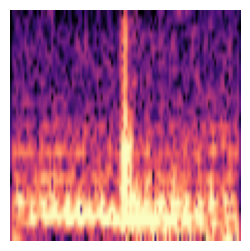

In [12]:
get_x_pred(0).show()

In [13]:
def pipeline(ha_model: Learner) -> list:
    result = []

    for i in range(len(spec)):
        if autoencoder_result(get_x_pred(i)) == 1:
            if predictor.predict(get_x_classify(i))[0] == 'Fall':
                result.append(ha_model.predict(get_x_classify(i))[0])
            else:
                result.append("Not Fall")
        else:
            result.append("Not Fall")
    
    return result

In [14]:
main_result = pipeline(classifier)

In [15]:
hybrid_result = pipeline(hybrid)

In [16]:
classic_result = pipeline(classic)

In [17]:
main_result

['SlipTrip',
 'Not Fall',
 'Not Fall',
 'SlipTrip',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Controlled Fall',
 'Hard Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Controlled Fall',
 'Not Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Hard Fall',
 'Hard Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Hard Fall',
 'Hard Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Hard Fall',
 'Controlled Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Hard Fall',
 'Hard Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Hard Fall',
 'Hard Fall',
 'Not Fall',
 'Hard Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Ha

In [18]:
labels

['Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Not Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fall',
 'Controlled Fal

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [20]:
accuracy_score(pred_label, result_1)

0.9681372549019608

In [21]:
accuracy_score(labels, main_result)

0.8284313725490197

In [22]:
pred_block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x_pred,
    get_y=get_y_pred,
)

block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x_classify,
    get_y=get_y_classify,
)

pred_items = list(range(len(pred_spec)))
items = list(range(len(spec)))

pred_dls = pred_block.dataloaders(pred_items, bs=16)
dls = block.dataloaders(items, bs=16)

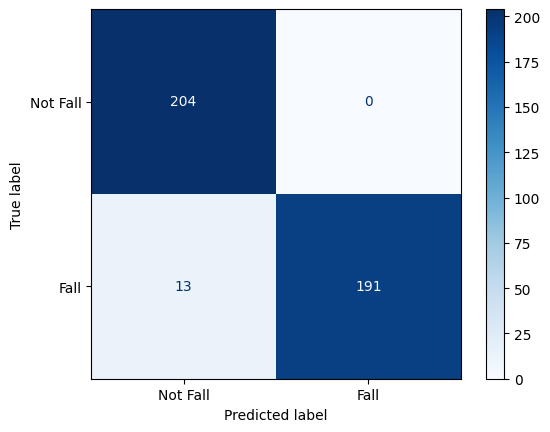

In [24]:
cm = confusion_matrix(pred_label, result_1, labels=["Not Fall", "Fall"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Fall", "Fall"])
disp.plot(cmap="Blues")  # customize as you like
plt.show()

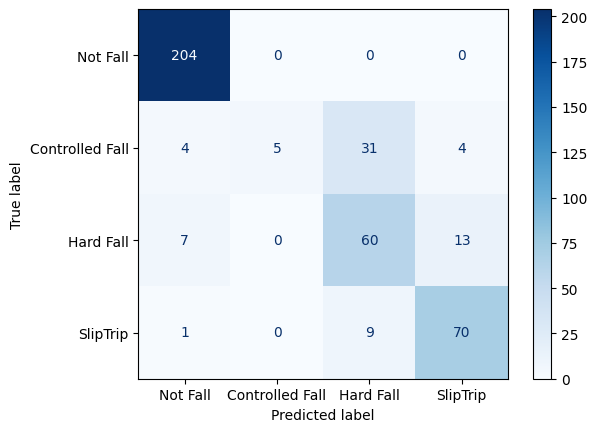

In [46]:
cm = confusion_matrix(labels, main_result, labels=dls.vocab)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

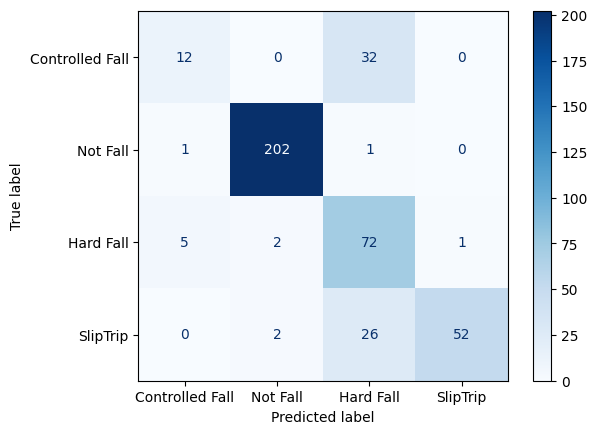

In [66]:
cm = confusion_matrix(labels, hybrid_result, labels=dls.vocab)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

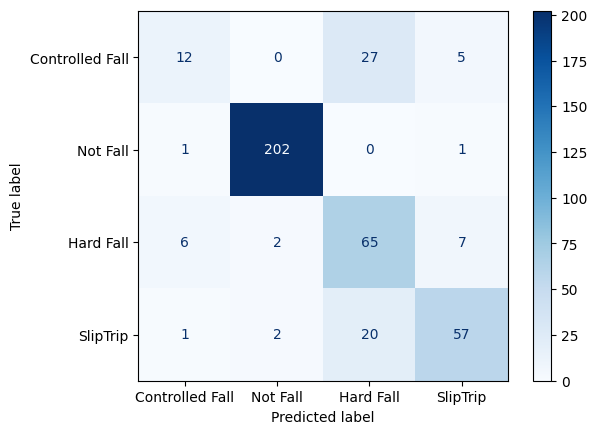

In [67]:
cm = confusion_matrix(labels, classic_result, labels=dls.vocab)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()